# Chương 1 – Lịch sử AI và dữ liệu minh họa
Lịch sử chi tiết và tài liệu gốc nằm trong báo cáo. Notebook minh họa sự khác nhau giữa dữ liệu bảng, ảnh và chuỗi, không gán các mô hình hiện đại thành kết quả lịch sử.

In [1]:
import os,sys,json
from pathlib import Path
os.environ['OPENBLAS_NUM_THREADS']='2'
os.environ['OMP_NUM_THREADS']='2'
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/experiment.py').exists())
sys.path.insert(0,str(ROOT/'src'))
from IPython.display import display,Image,Code


In [2]:
import numpy as np,pandas as pd

## Ba dataset đại diện
CDC: bảng khảo sát; MNIST: ảnh chữ số; AAPL: chuỗi OHLCV. Mỗi nguồn có quy mô, mẫu nhãn, phân bố và giới hạn riêng. Cùng một metric không dùng để so khác bài toán.

kind                                                       mlp
task                                            classification
classes                 [No diabetes, Prediabetes or diabetes]
raw_rows                                                253680
features     [HighBP, HighChol, CholCheck, BMI, Smoker, Str...
source       https://www.kaggle.com/datasets/alexteboul/dia...
protocol     Group by identical predictors; bounded stratif...
transform                                       train mean/std
mean         [0.45381250977516174, 0.43712499737739563, 0.9...
std          [0.4978955388069153, 0.4960578382015228, 0.190...
key                                                   diabetes
shape                                                     [21]
samples                                                  25000
splits             {'train': 16000, 'val': 4000, 'test': 5000}
counts       {'train': [13227, 2773], 'val': [3319, 681], '...
dtype: object

Một số target: [0 0 0 0 0]


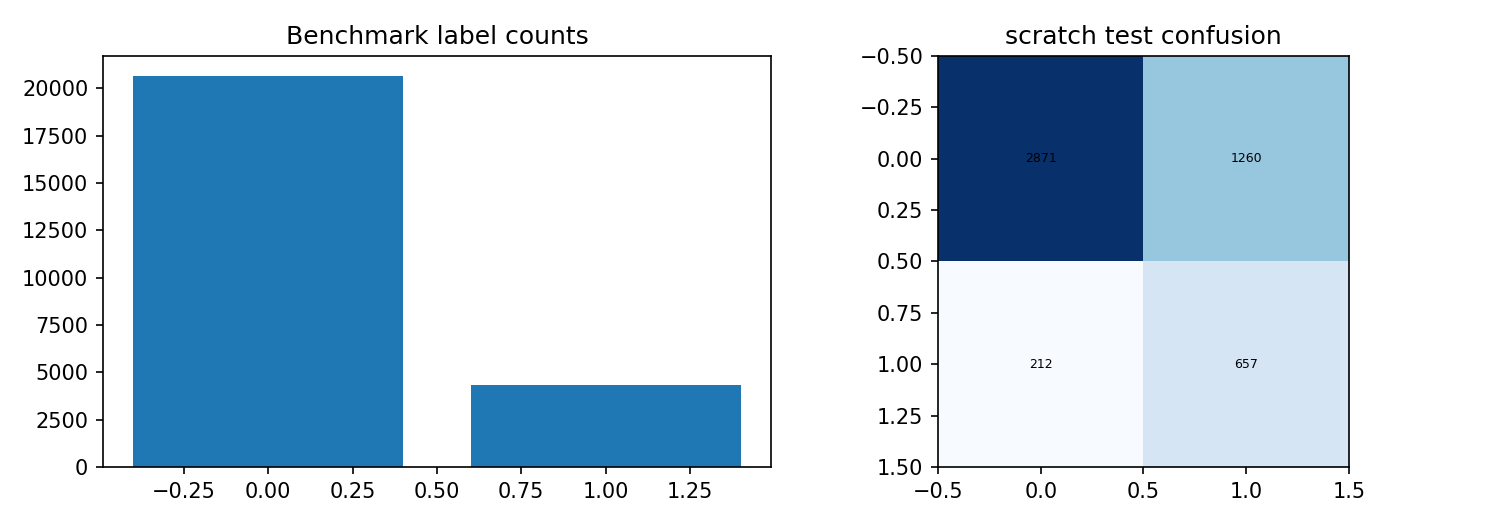

kind                                                       cnn
task                                            classification
classes                         [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
raw_rows                                                 70000
mean                                     [0.13107748329639435]
std                                       [0.2632492780685425]
source       https://storage.googleapis.com/tensorflow/tf-k...
protocol     Fixed stratified benchmark subset; MNIST prese...
transform    Resize16 bilinear /255 then train channel mean...
key                                                      mnist
shape                                              [16, 16, 1]
samples                                                  14000
splits             {'train': 10000, 'val': 2000, 'test': 2000}
counts       {'train': [987, 1124, 993, 1022, 974, 904, 986...
dtype: object

Một số target: [6 5 8 5 8]


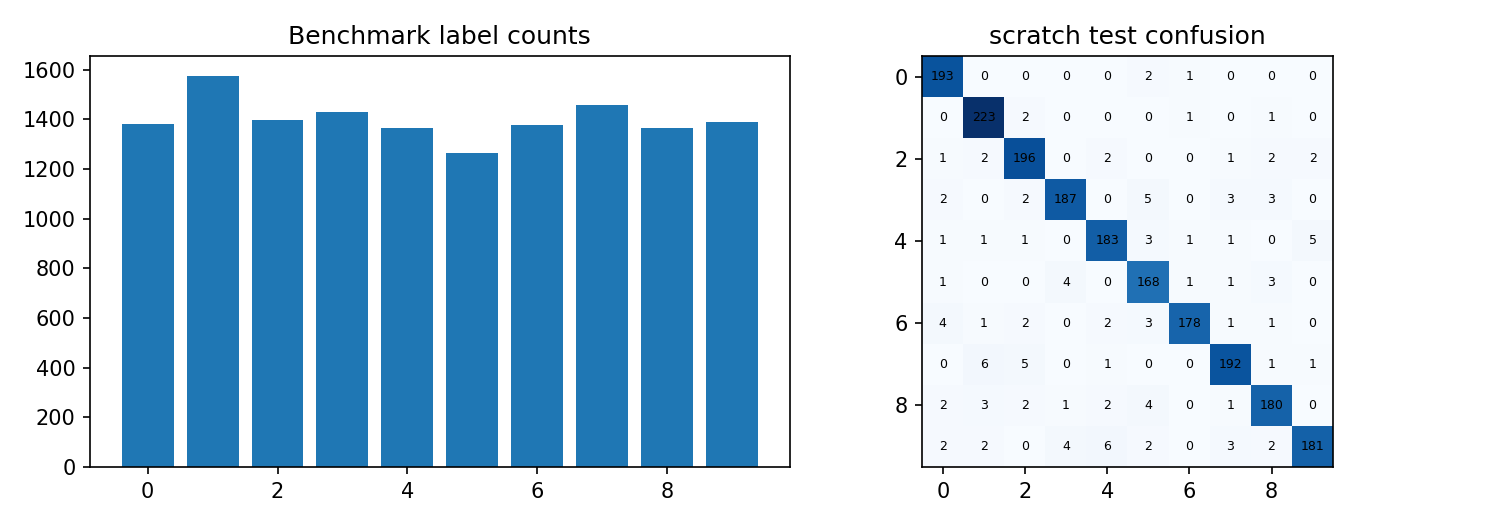

kind                                                       rnn
task                                                regression
classes                                [No purchase, Purchase]
raw_rows                                                  2766
source       https://github.com/tuananhtrieu1305/ISD_Assign...
protocol     Chronological 70/15/15 by target date; feature...
transform       Causal OHLCV indicators, train standardization
features     [LogReturn, OpenGap, Range, Body, RelativeMA20...
mean         [0.0008318194886669517, 0.0002356943441554904,...
std          [0.01866917684674263, 0.012287449091672897, 0....
y_mean                                                 0.00076
y_std                                                 0.018754
periods      {'train': ['2015-04-28', '2022-10-12'], 'valid...
details      {'dataset': 'AAPL historical stock', 'raw_rows...
key                                                      stock
shape                                                  

Một số target: [-0.01588116 -0.01481507 -0.02750477  0.02991168 -0.00194062]


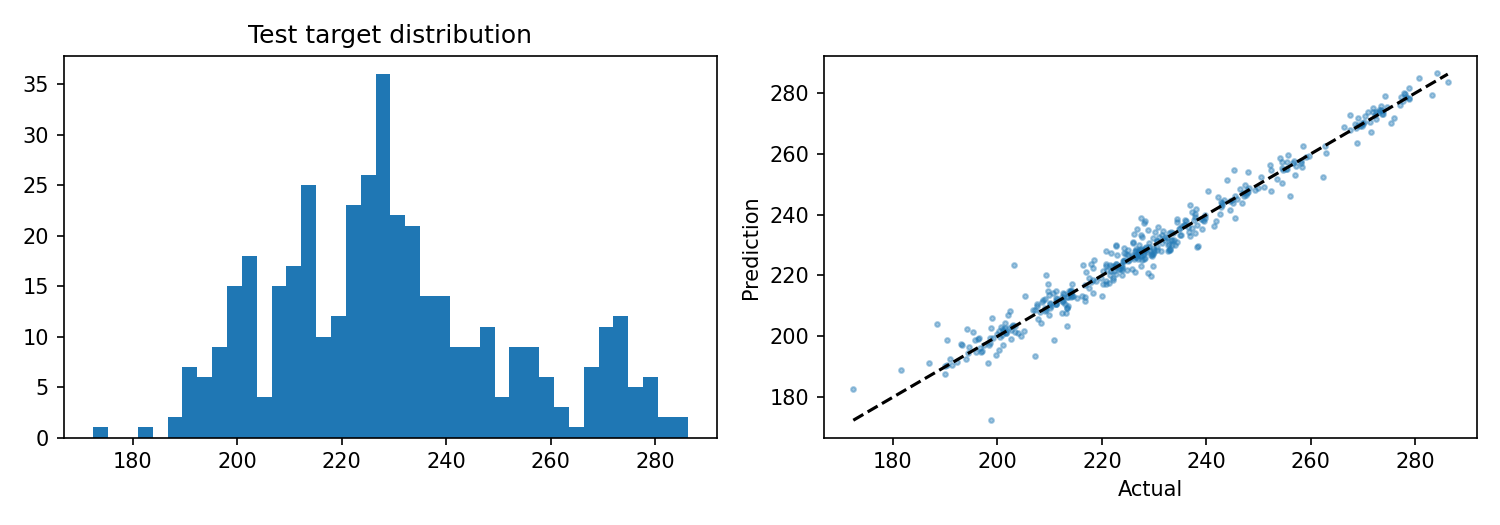

In [3]:
for key in ['diabetes','mnist','stock']:
    meta=json.loads((ROOT/'results'/key/'summary.json').read_text(encoding='utf-8'))
    display(pd.Series(meta))
    d=np.load(ROOT/'data'/f'{key}.npz')
    print('Một số target:',d['raw_y'][:5])
    path=ROOT/'results'/key/'evaluation.png'
    if path.exists():display(Image(filename=str(path)))

## Kiểm tra gradient scratch
Finite differences kiểm tra độc lập đạo hàm; sau đó đối chiếu autograd PyTorch/Keras trên cùng trọng số. Sai số nhỏ chỉ xác nhận phép toán, không bảo đảm mô hình dự đoán tốt.

In [4]:
display(pd.read_json(ROOT/'results/gradient_checks.json'))

,kind,framework_gradient_max_error,finite_difference_max_error,status
0,mlp,1.192093e-07,1.719760e-08,passed
1,cnn,8.940697e-08,1.387893e-08,passed
2,rnn,4.470348e-08,1.174102e-08,passed
